# Energize Your Stock Clustering

In this activity, you’ll use the K-means algorithm and clustering optimization techniques to cluster stocks. The purpose will be to define a portfolio investment strategy.

Instructions

1. Read in the `tsx-energy-2018.csv` file from the `Resources` folder and create the DataFrame. Make sure to set the `Ticker` column as the DataFrame’s index. Then review the DataFrame.

2. Review the four code cells that are included in this step in the notebook. These cells contain the code that scales the `df_stocks` DataFrame and creates a new DataFrame that contains the scaled data. 

    > **Hint** The four code cells included in this step in the notebook mirror the steps in the “Standardized Stocks Data” activity that you completed earlier in this lesson. Be sure to run these cells before moving on to Step 3. 

3. Using the `df_stocks_scaled` DataFrame, cluster the data by using the K-means algorithm and a lowercase-k value of  3. Add the resulting list of company segment values as a new column in the `df_stocks_scaled` DataFrame. 

    > **Rewind** You can use a lowercase-k value of 3 to start, or you can use the elbow method to find the optimal value for lowercase-k.

4. Using hvPlot, create a scatter plot to visualize the clusters setting `x="AnnualVariance"`,  `y="Annual Return"`, and `by="StockCluster"`. Be sure to style and format your plot.

    > **Rewind** Remember that you can style your plot using hvPlot’s customization parameters. For example, you can add the ticker symbol to the tooltip of each point by using hvPlot’s `hover_cols` parameter. For a refresher on customizing `hvplot`, refer to [Customization](https://hvplot.holoviz.org/user_guide/Customization.html) in the hvPlot user guide.

5. To get another perspective on the clusters, reduce the number of features to two principal components by using PCA. Make sure to do the following: 

    - Use the `df_stocks_scaled` DataFrame to complete this analysis. 

    - Review the PCA data. 

    - Calculate the explained variance ratio that results from the PCA data. 

6. Using the PCA data calculated in the previous step, create a new DataFrame called `df_stocks_pca`. Make sure to do the following: 

    - Add an additional column to the DataFrame that contains the tickers from the original `df_stocks` DataFrame. 

    - Set the new Tickers column as the index. 

    - Review the DataFrame.

7. Rerun the K-means algorithm with the new principal-components data, and then create a scatter plot by using the two principal components for the x and y axes, and by using `StockCluster`. Be sure to style and format your plot.



References

[scikit-learn PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

[scikit-learn StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

[scikit-learn Preprocessing Data](https://scikit-learn.org/stable/modules/preprocessing.html#preprocessing-scaler)

[scikit-learn Python Library](https://scikit-learn.org)

[HvPlot Customization](https://hvplot.holoviz.org/user_guide/Customization.html)

In [4]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Step 1: Read in the `tsx-energy-2018.csv` file from the `Resources` folder and create the DataFrame. Make sure to set the `Ticker` column as the DataFrame’s index. Then review the DataFrame.

In [5]:
# Read the CSV file into a Pandas DataFrame
# Set the index using the Ticker column
df_stocks = pd.read_csv(
    Path("10.4/01-Standardizing_Stock_Data/Resources/tsx-energy-2018.csv"), 
    index_col="Ticker"
)

# Review the DataFrame
df_stocks.head()

,CompanyName,MeanOpen,MeanHigh,MeanLow,MeanClose,MeanVolume,AnnualReturn,AnnualVariance,EnergyType
Ticker,,,,,,,,,
ARX,ARC Resources Ltd.,13.14,13.34,12.91,13.10,1479913.38,-0.7275,0.3590,Oil
CCO,Cameco Corporation,13.70,13.92,13.50,13.70,1203788.22,0.2014,0.3693,Other Energy
CNQ,Canadian Natural Resources Limited,41.97,42.46,41.46,41.91,3218248.68,-0.3461,0.2947,Oil
CVE,Cenovus Energy Inc.,11.96,12.18,11.75,11.95,4566143.56,-0.3219,0.4500,Oil
CPG,Crescent Point Energy Corp.,8.53,8.67,8.36,8.50,3919414.03,-1.0103,0.4597,Other Energy


## Step 2: Review the four code cells that are included in this step in the notebook. These cells contain the code that scales the `df_stocks` DataFrame and creates a new DataFrame that contains the scaled data. 

    > **Hint** The four code cells included in this step in the notebook mirror the steps in the “Standardized Stocks Data” activity that you completed earlier in this lesson. Be sure to run these cells before moving on to Step 3.  


In [7]:
# Scale price data, return, and variance values
stock_data_scaled = StandardScaler().fit_transform(
    df_stocks[["MeanOpen", "MeanHigh", "MeanLow", "MeanClose", "MeanVolume", "AnnualReturn", "AnnualVariance"]]
)
stock_data_scaled[:5]

array([[-0.91683187, -0.91721692, -0.91804499, -0.9181346 , -0.15278563,
        -1.33244548,  0.46085356],
       [-0.88015205, -0.87947182, -0.87906242, -0.87878597, -0.37911694,
         1.69574215,  0.55941139],
       [ 0.97152411,  0.97784771,  0.96831488,  0.97125524,  1.27207441,
        -0.08909231, -0.15441525],
       [-0.9941215 , -0.99270713, -0.99468868, -0.9935528 ,  2.37690243,
        -0.01020099,  1.33160722],
       [-1.21878543, -1.2211301 , -1.21867327, -1.2198074 ,  1.8467981 ,
        -2.25436545,  1.42442382]])

In [8]:
# Create a DataFrame with the scaled data
df_stocks_scaled = pd.DataFrame(
    stock_data_scaled,
    columns = ["MeanOpen", "MeanHigh", "MeanLow", "MeanClose", "MeanVolume", "AnnualReturn", "AnnualVariance"]
)

# Copy the tickers names from the original data
df_stocks_scaled['Ticker'] = df_stocks.index

# Set the Ticker column as index
df_stocks_scaled = df_stocks_scaled.set_index("Ticker")

df_stocks_scaled.head()

,MeanOpen,MeanHigh,MeanLow,MeanClose,MeanVolume,AnnualReturn,AnnualVariance
Ticker,,,,,,,
ARX,-0.916832,-0.917217,-0.918045,-0.918135,-0.152786,-1.332445,0.460854
CCO,-0.880152,-0.879472,-0.879062,-0.878786,-0.379117,1.695742,0.559411
CNQ,0.971524,0.977848,0.968315,0.971255,1.272074,-0.089092,-0.154415
CVE,-0.994122,-0.992707,-0.994689,-0.993553,2.376902,-0.010201,1.331607
CPG,-1.218785,-1.221130,-1.218673,-1.219807,1.846798,-2.254365,1.424424


In [9]:
# Encode (convert to dummy variables) the `EnergyType` column, which categorizes oil versus non-oil firms
oil_dummies = pd.get_dummies(df_stocks['EnergyType'])
oil_dummies.head()

,Oil,Other Energy
Ticker,,
ARX,True,False
CCO,False,True
CNQ,True,False
CVE,True,False
CPG,False,True


In [10]:
# Concatenate the `EnergyType` encoded dummies with the scaled data DataFrame
df_stocks_scaled = pd.concat([df_stocks_scaled, oil_dummies],axis = 1)

df_stocks_scaled.head()

,MeanOpen,MeanHigh,MeanLow,MeanClose,MeanVolume,AnnualReturn,AnnualVariance,Oil,Other Energy
Ticker,,,,,,,,,
ARX,-0.916832,-0.917217,-0.918045,-0.918135,-0.152786,-1.332445,0.460854,True,False
CCO,-0.880152,-0.879472,-0.879062,-0.878786,-0.379117,1.695742,0.559411,False,True
CNQ,0.971524,0.977848,0.968315,0.971255,1.272074,-0.089092,-0.154415,True,False
CVE,-0.994122,-0.992707,-0.994689,-0.993553,2.376902,-0.010201,1.331607,True,False
CPG,-1.218785,-1.221130,-1.218673,-1.219807,1.846798,-2.254365,1.424424,False,True


## Step 3: Using the `df_stocks_scaled` DataFrame, cluster the data by using the K-means algorithm and a lowercase-k value of  3. Add the resulting list of company segment values as a new column in the `df_stocks_scaled` DataFrame. 

> **Rewind** You can use a lowercase-k value of 3 to start, or you can use the elbow method to find the optimal value for lowercase-k.

In [11]:
# Initialize the K-Means model with n_clusters=3
model = KMeans(n_clusters=3)

model.fit(df_stocks_scaled)

KMeans(n_clusters=3)

In [12]:
# Predict the model segments (clusters)
stock_clusters = model.predict(df_stocks_scaled)

print(stock_clusters)

[0 2 1 2 0 1 2 2 2 1 0 1 2 0 2 1 1 0 0 1 1 1 1 0]


In [13]:
# Create a new column in the DataFrame with the predicted clusters
df_stocks_scaled["StockCluster"] = stock_clusters

# Review the DataFrame
df_stocks_scaled.head()

,MeanOpen,MeanHigh,MeanLow,MeanClose,MeanVolume,AnnualReturn,AnnualVariance,Oil,Other Energy,StockCluster
Ticker,,,,,,,,,,
ARX,-0.916832,-0.917217,-0.918045,-0.918135,-0.152786,-1.332445,0.460854,True,False,0
CCO,-0.880152,-0.879472,-0.879062,-0.878786,-0.379117,1.695742,0.559411,False,True,2
CNQ,0.971524,0.977848,0.968315,0.971255,1.272074,-0.089092,-0.154415,True,False,1
CVE,-0.994122,-0.992707,-0.994689,-0.993553,2.376902,-0.010201,1.331607,True,False,2
CPG,-1.218785,-1.221130,-1.218673,-1.219807,1.846798,-2.254365,1.424424,False,True,0


## Step 4: Using hvPlot, create a scatter plot to visualize the clusters setting `x="AnnualVariance"`,  `y="Annual Return"`, and `by="StockCluster"`. Be sure to style and format your plot.

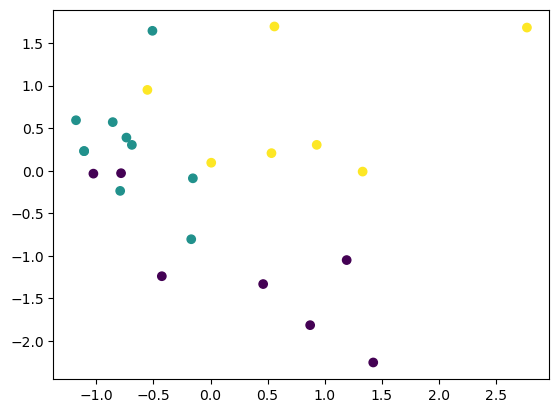

In [15]:
plt.scatter(df_stocks_scaled['AnnualVariance'],df_stocks_scaled['AnnualReturn'], c = df_stocks_scaled['StockCluster'])

## Step 5: o get another perspective on the clusters, reduce the number of features to two principal components by using PCA. Make sure to do the following: 

    - Use the `df_stocks_scaled` DataFrame to complete this analysis. 

    - Review the PCA data. 

    - Calculate the explained variance ratio that results from the PCA data. 


In [16]:
# Create the PCA model instance where n_components=2
pca = PCA(n_components=2)

In [20]:
# Fit the df_stocks_scaled data to the PCA
stocks_pca_data = pca.fit_transform(df_stocks_scaled)

# Review the first five rose of the PCA data
# using bracket notation ([0:5])
stocks_pca_data[:5]

array([[-1.99985949, -1.45476095],
       [-1.64698621,  2.25763364],
       [ 1.86575533, -0.83669191],
       [-2.28389741, -0.32116994],
       [-3.05583757, -2.39092783]])

In [21]:
# Calculate the explained variance
pca.explained_variance_ratio_

array([0.57861466, 0.1780315 ])

## Step 6: Using the PCA data calculated in the previous step, create a new DataFrame called `df_stocks_pca`. Make sure to do the following: 

* Add an additional column to the DataFrame that contains the tickers from the original `df_stocks` DataFrame. 

* Set the new Tickers column as the index. 

* Review the DataFrame.


In [22]:
# Creating a DataFrame with the PCA data
df_stocks_pca = pd.DataFrame(stocks_pca_data, columns=["PC1", "PC2"])

# Copy the tickers names from the original data
df_stocks_pca["Ticker"] = df_stocks.index

# Set the Ticker column as index
df_stocks_pca = df_stocks_pca.set_index("Ticker")

# Review the DataFrame
df_stocks_pca.head()

,PC1,PC2
Ticker,,
ARX,-1.999859,-1.454761
CCO,-1.646986,2.257634
CNQ,1.865755,-0.836692
CVE,-2.283897,-0.321170
CPG,-3.055838,-2.390928


## Step 7: Rerun the K-means algorithm with the new principal-components data, and then create a scatter plot by using the two principal components for the x and y axes, and by using `StockCluster`. Be sure to style and format your plot.

In [23]:
# Initialize the K-Means model with n_clusters=3
model = KMeans(n_clusters=3)

# Fit the model for the df_stocks_pca DataFrame
model.fit(df_stocks_pca)

# Predict the model segments (clusters)
stock_clusters = model.predict(df_stocks_pca)

# View the stock segments
print(stock_clusters)

[1 2 0 1 1 0 2 2 2 0 2 0 2 2 2 0 0 1 1 0 0 0 0 1]


In [24]:
# Create a copy of the df_stocks_pca DataFrame and name it as df_stocks_pca_predictions
df_stocks_pca_predictions = df_stocks_pca.copy()

# Create a new column in the DataFrame with the predicted clusters
df_stocks_pca_predictions["StockCluster"] = stock_clusters

# Review the DataFrame
df_stocks_pca_predictions.head()

,PC1,PC2,StockCluster
Ticker,,,
ARX,-1.999859,-1.454761,1
CCO,-1.646986,2.257634,2
CNQ,1.865755,-0.836692,0
CVE,-2.283897,-0.321170,1
CPG,-3.055838,-2.390928,1


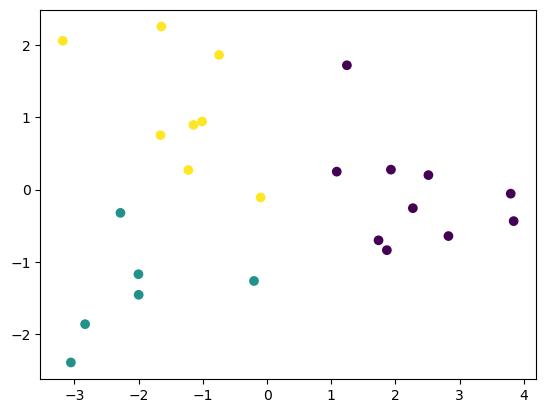

In [25]:
plt.scatter(df_stocks_pca_predictions["PC1"],df_stocks_pca_predictions["PC2"],c=df_stocks_pca_predictions["StockCluster"])